# Clustering incrementale dei pattern di criminalita

In [5]:
import time
import warnings
from pathlib import Path

import influxdb_client
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from influxdb_client.client.warnings import MissingPivotFunction
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

org_name = "spamic"
token = "6ANpdrZyP8Nk7HBib5puP7dx8fJrFNG2xCPlBiXqDSKAsSfjKsUMPlgEVvoQMllyP0HCDAlherDBZZA_z42utw=="
url = "http://localhost:8086"
bucket_name = "lapd_crime_data"

client = influxdb_client.InfluxDBClient(url=url, token=token, org=org_name, timeout=600000)
query_api = client.query_api()

warnings.simplefilter(action="ignore", category=MissingPivotFunction)

MEASUREMENT_NAME = "crime_daily"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

N_CLUSTERS = 4
N_CLUSTER_CANDIDATES = [2, 3, 4, 5, 6]
CLUSTER_BATCH_SIZE = 32

CLUSTER_COLORS = {
    -1: "#d9d9d9",
    0: "#80b1d3",
    1: "#8dd3c7",
    2: "#fdb462",
    3: "#bebada"
}


In [6]:
def run_query(flux_query):
    t0 = time.perf_counter()
    df = query_api.query_data_frame(flux_query)
    t1 = time.perf_counter()

    if isinstance(df, list):
        frames = [x for x in df if isinstance(x, pd.DataFrame) and not x.empty]
        if frames:
            df = pd.concat(frames, ignore_index=True)
        else:
            df = pd.DataFrame()

    if not df.empty and "_time" in df.columns:
        df["_time"] = pd.to_datetime(df["_time"], errors="coerce")

    return df, (t1 - t0)


def clustering_query(start="2020-01-01T00:00:00Z", stop="2025-11-30T23:59:59Z"):
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "crime_count" or r._field == "weapon_count" or r._field == "violent_count")
      |> keep(columns: ["_time", "_field", "_value", "area_name", "season", "time_band", "year"])
    '''


In [7]:
raw_df, query_time = run_query(clustering_query())
print(f"Righe lette da Influx: {len(raw_df)}")
print(f"Tempo query sorgente: {query_time:.3f} secondi")
raw_df.head()

Righe lette da Influx: 2031201
Tempo query sorgente: 279.923 secondi


,result,table,_time,_value,_field,area_name,season,time_band,year
0,_result,0,2020-09-05 12:00:00+00:00,1,crime_count,77th Street,autumn,day,2020
1,_result,0,2020-09-06 12:00:00+00:00,1,crime_count,77th Street,autumn,day,2020
2,_result,0,2020-09-08 12:00:00+00:00,1,crime_count,77th Street,autumn,day,2020
3,_result,0,2020-09-11 12:00:00+00:00,1,crime_count,77th Street,autumn,day,2020
4,_result,0,2020-09-20 12:00:00+00:00,1,crime_count,77th Street,autumn,day,2020


In [8]:
wide_df = raw_df.pivot_table(
    index=["_time", "area_name", "season", "time_band", "year"],
    columns="_field",
    values="_value",
    aggfunc="first"
).reset_index()

wide_df["crime_count"] = pd.to_numeric(wide_df["crime_count"], errors="coerce").fillna(0)
wide_df["weapon_count"] = pd.to_numeric(wide_df["weapon_count"], errors="coerce").fillna(0)
wide_df["violent_count"] = pd.to_numeric(wide_df["violent_count"], errors="coerce").fillna(0)
wide_df["year"] = pd.to_numeric(wide_df["year"], errors="coerce").astype("Int64")

wide_df["night_crime_count"] = wide_df.apply(
    lambda row: row["crime_count"] if row["time_band"] == "night" else 0,
    axis=1
)

feature_df = (
    wide_df.groupby(["area_name", "season", "year"], as_index=False)
    .agg(
        crime_count=("crime_count", "sum"),
        weapon_count=("weapon_count", "sum"),
        violent_count=("violent_count", "sum"),
        night_crime_count=("night_crime_count", "sum")
    )
)

feature_df = feature_df[feature_df["crime_count"] > 0].copy()
feature_df["weapon_pct"] = (feature_df["weapon_count"] / feature_df["crime_count"]) * 100.0
feature_df["night_pct"] = (feature_df["night_crime_count"] / feature_df["crime_count"]) * 100.0
feature_df["violent_pct"] = (feature_df["violent_count"] / feature_df["crime_count"]) * 100.0

feature_df = feature_df[[
    "area_name", "season", "year", "crime_count", "weapon_pct", "night_pct", "violent_pct"
]].sort_values(["year", "season", "area_name"]).reset_index(drop=True)

feature_df.head()

,area_name,season,year,crime_count,weapon_pct,night_pct,violent_pct
0,77th Street,autumn,2020,305,98.032787,47.213115,96.393443
1,Central,autumn,2020,284,92.957746,52.112676,91.197183
2,Devonshire,autumn,2020,231,49.350649,50.216450,45.887446
3,Foothill,autumn,2020,238,64.285714,49.159664,58.403361
4,Harbor,autumn,2020,243,71.193416,54.732510,70.781893


In [9]:
features = ["crime_count", "weapon_pct", "night_pct", "violent_pct"]
years = sorted(feature_df["year"].dropna().unique())

scaler = StandardScaler()
for year in years:
    scaler.partial_fit(feature_df.loc[feature_df["year"] == year, features])

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    batch_size=CLUSTER_BATCH_SIZE,
    n_init=10
)

for year in years:
    X_year = scaler.transform(feature_df.loc[feature_df["year"] == year, features])
    kmeans.partial_fit(X_year)

X_scaled = scaler.transform(feature_df[features])
feature_df["cluster"] = kmeans.predict(X_scaled)

feature_df.head()

c:\Users\Spazzo\anaconda3\envs\sistemi-evolutivi-big-data\Lib\site-packages\sklearn\cluster\_kmeans.py:1962: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


,area_name,season,year,crime_count,weapon_pct,night_pct,violent_pct,cluster
0,77th Street,autumn,2020,305,98.032787,47.213115,96.393443,3
1,Central,autumn,2020,284,92.957746,52.112676,91.197183,2
2,Devonshire,autumn,2020,231,49.350649,50.216450,45.887446,0
3,Foothill,autumn,2020,238,64.285714,49.159664,58.403361,0
4,Harbor,autumn,2020,243,71.193416,54.732510,70.781893,1


In [10]:
cluster_profile = (
    feature_df.groupby("cluster", as_index=False)[features]
    .mean()
    .sort_values("cluster")
)

print("Profili medi dei cluster")
display(cluster_profile)

Profili medi dei cluster


,cluster,crime_count,weapon_pct,night_pct,violent_pct
0,0,246.549738,43.858475,50.568573,39.970565
1,1,249.907692,75.775364,51.604323,73.962009
2,2,304.322581,82.224162,53.268117,80.532683
3,3,276.485294,86.922902,47.856578,85.388443


In [11]:
print(sorted(feature_df["year"].dropna().unique()))

[2020, 2021, 2022, 2023, 2024]


In [12]:
first_year = int(min(years))
last_year = int(max(years))

compare_df = feature_df[feature_df["year"].isin([first_year, last_year])].copy()
cluster_change = compare_df.pivot_table(
    index=["area_name", "season"],
    columns="year",
    values="cluster",
    aggfunc="first"
).reset_index()

for y in [first_year, last_year]:
    if y not in cluster_change.columns:
        cluster_change[y] = pd.NA

cluster_change = cluster_change.rename(columns={
    first_year: f"cluster_{first_year}",
    last_year: f"cluster_{last_year}"
})

cluster_change["changed"] = (
    cluster_change[f"cluster_{first_year}"].notna() &
    cluster_change[f"cluster_{last_year}"].notna() &
    (cluster_change[f"cluster_{first_year}"] != cluster_change[f"cluster_{last_year}"])
)

valid_comparisons = cluster_change[
    cluster_change[f"cluster_{first_year}"].notna() &
    cluster_change[f"cluster_{last_year}"].notna()
].copy()

if len(valid_comparisons) > 0:
    change_rate = valid_comparisons["changed"].mean() * 100.0
    print(f"Percentuale combinazioni area-stagione che cambiano cluster tra {first_year} e {last_year}: {change_rate:.2f}%")
else:
    print(f"Nessun confronto diretto disponibile tra {first_year} e {last_year}: manca almeno uno dei due anni nei dati.")

display(cluster_change.head(30))

Percentuale combinazioni area-stagione che cambiano cluster tra 2020 e 2024: 50.00%


year,area_name,season,cluster_2020,cluster_2024,changed
0,77th Street,autumn,3,0,True
1,77th Street,spring,3,2,True
2,77th Street,summer,2,0,True
3,77th Street,winter,3,3,False
4,Central,autumn,2,2,False
5,Central,spring,1,0,True
6,Central,summer,3,2,True
7,Central,winter,1,2,True
8,Devonshire,autumn,0,0,False
9,Devonshire,spring,0,0,False


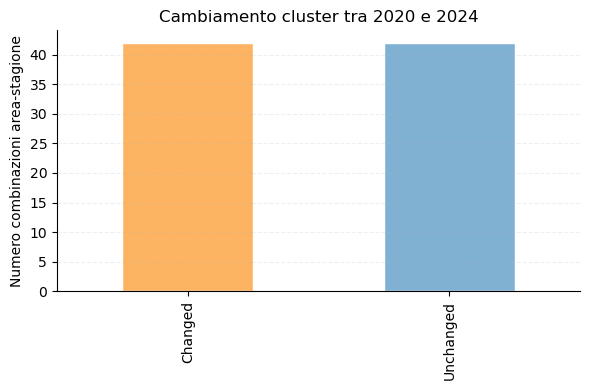

In [13]:
change_summary = (
    cluster_change["changed"]
    .value_counts(dropna=False)
    .rename(index={True: "Changed", False: "Unchanged"})
    .reindex(["Changed", "Unchanged"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(6, 4))
change_summary.plot(
    kind="bar",
    color=["#fdb462", "#80b1d3"],
    edgecolor="white",
    linewidth=1,
    ax=ax
)
ax.set_title(f"Cambiamento cluster tra {first_year} e {last_year}")
ax.set_ylabel("Numero combinazioni area-stagione")
ax.set_xlabel("")
ax.yaxis.grid(True, linestyle="--", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"q3_cluster_change_bar_{first_year}_{last_year}.png", dpi=150, bbox_inches="tight")
plt.show()

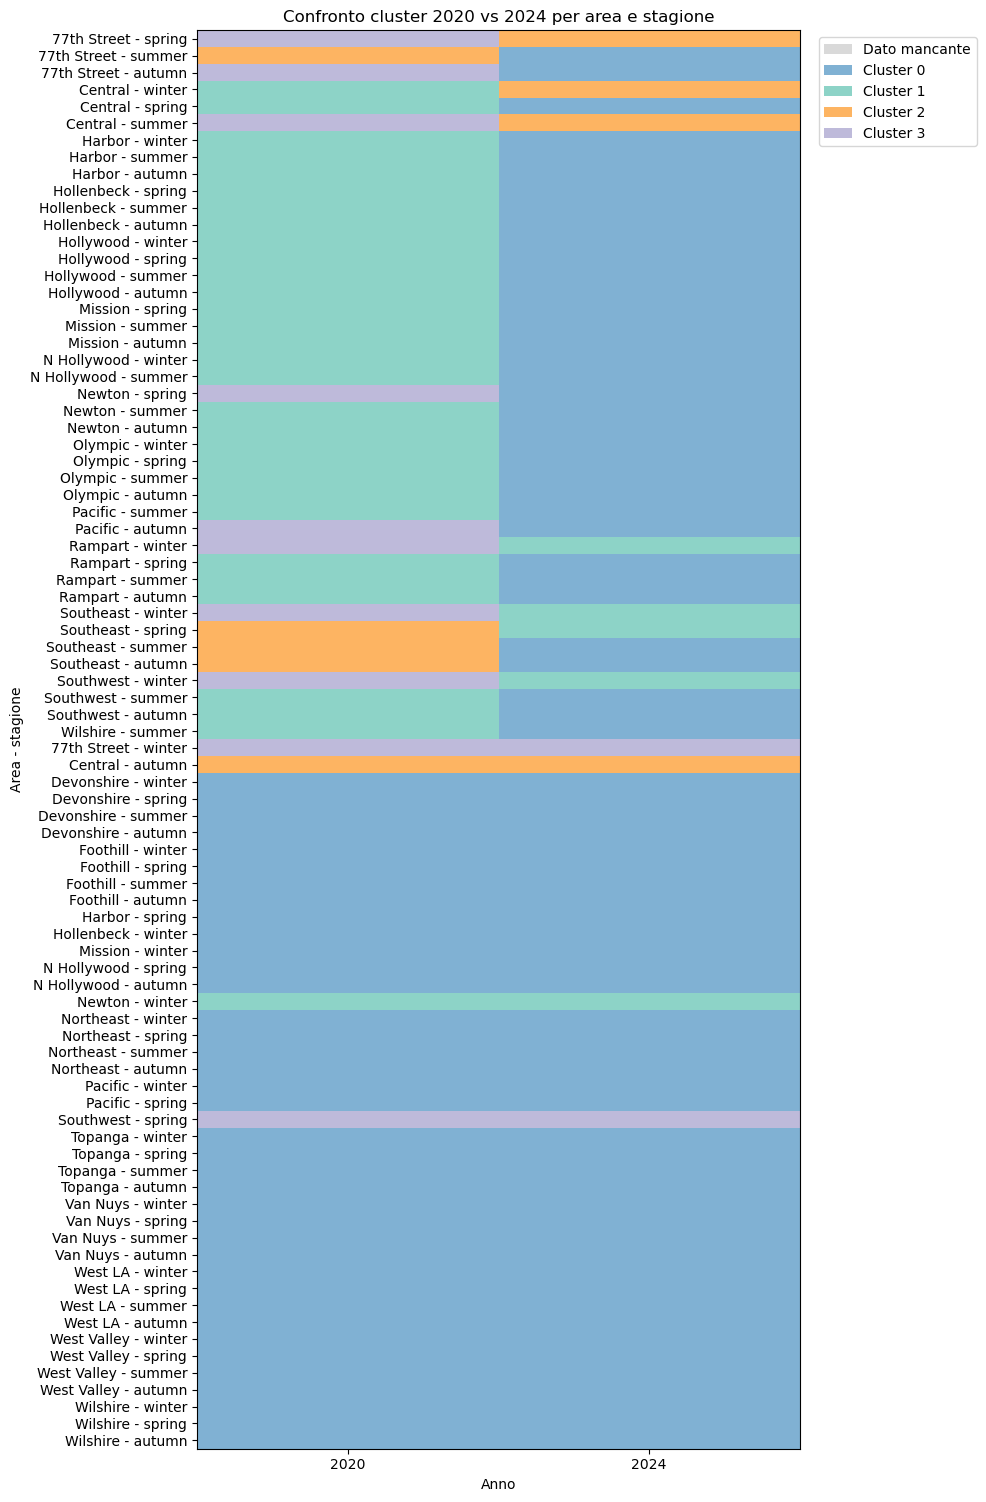

In [14]:
season_order = ["winter", "spring", "summer", "autumn"]
heatmap_df = cluster_change.copy()
heatmap_df["season"] = pd.Categorical(heatmap_df["season"], categories=season_order, ordered=True)
heatmap_df = heatmap_df.sort_values(["changed", "area_name", "season"], ascending=[False, True, True])
heatmap_df["label"] = heatmap_df["area_name"] + " - " + heatmap_df["season"].astype(str)

heatmap_cols = [f"cluster_{first_year}", f"cluster_{last_year}"]
heatmap_matrix = heatmap_df[["label"] + heatmap_cols].set_index("label")
heatmap_values = heatmap_matrix.apply(pd.to_numeric, errors="coerce").fillna(-1)

heatmap_palette = [CLUSTER_COLORS[-1], CLUSTER_COLORS[0], CLUSTER_COLORS[1], CLUSTER_COLORS[2], CLUSTER_COLORS[3]]
cmap = ListedColormap(heatmap_palette)

fig, ax = plt.subplots(figsize=(10, max(7, len(heatmap_values) * 0.18)))
ax.imshow(heatmap_values.values + 1, aspect="auto", cmap=cmap, vmin=0, vmax=len(heatmap_palette) - 1)
ax.set_xticks([0, 1])
ax.set_xticklabels([str(first_year), str(last_year)])
ax.set_yticks(range(len(heatmap_values.index)))
ax.set_yticklabels(heatmap_values.index)
ax.set_title(f"Confronto cluster {first_year} vs {last_year} per area e stagione")
ax.set_xlabel("Anno")
ax.set_ylabel("Area - stagione")

legend_handles = [
    Patch(facecolor=CLUSTER_COLORS[-1], edgecolor="none", label="Dato mancante"),
    Patch(facecolor=CLUSTER_COLORS[0], edgecolor="none", label="Cluster 0"),
    Patch(facecolor=CLUSTER_COLORS[1], edgecolor="none", label="Cluster 1"),
    Patch(facecolor=CLUSTER_COLORS[2], edgecolor="none", label="Cluster 2"),
    Patch(facecolor=CLUSTER_COLORS[3], edgecolor="none", label="Cluster 3")
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"q3_cluster_heatmap_{first_year}_{last_year}.png", dpi=150, bbox_inches="tight")
plt.show()

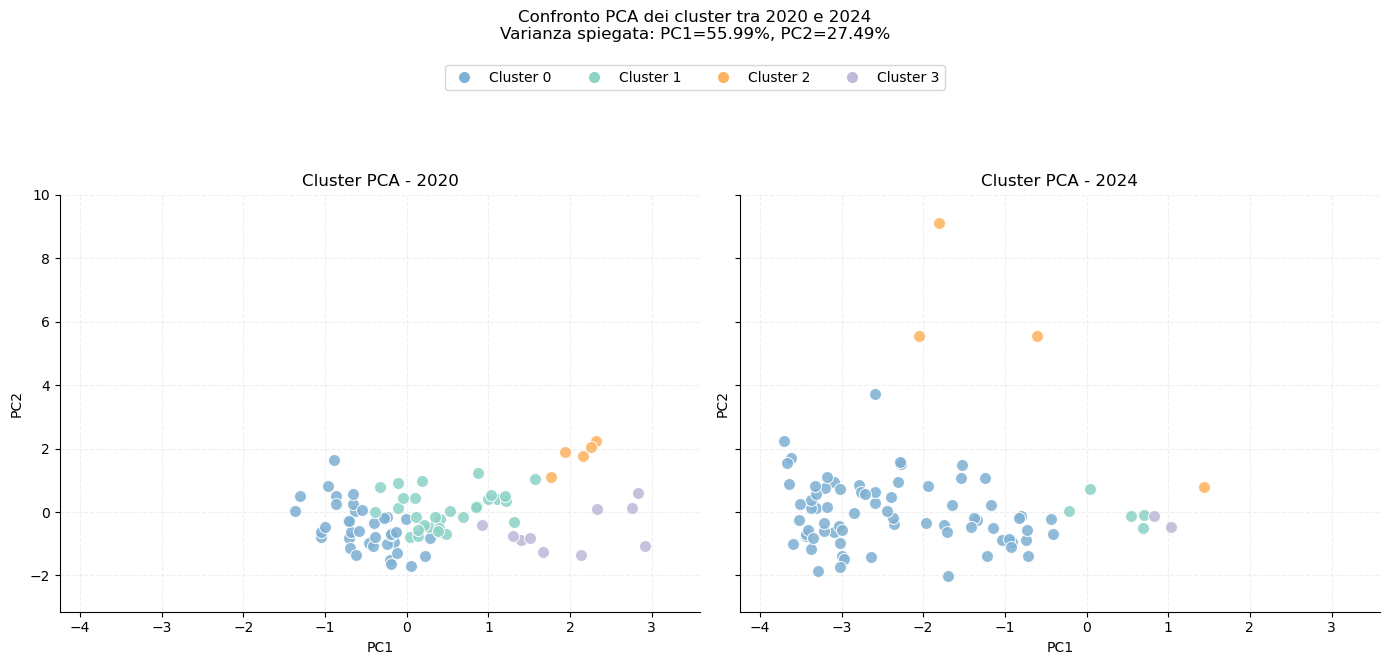

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plot_df = feature_df.copy()
plot_df["pc1"] = coords[:, 0]
plot_df["pc2"] = coords[:, 1]

plot_years = [first_year, last_year]
cluster_palette = [CLUSTER_COLORS[0], CLUSTER_COLORS[1], CLUSTER_COLORS[2], CLUSTER_COLORS[3]]

pc1_margin = (plot_df["pc1"].max() - plot_df["pc1"].min()) * 0.08
pc2_margin = (plot_df["pc2"].max() - plot_df["pc2"].min()) * 0.08
x_limits = (plot_df["pc1"].min() - pc1_margin, plot_df["pc1"].max() + pc1_margin)
y_limits = (plot_df["pc2"].min() - pc2_margin, plot_df["pc2"].max() + pc2_margin)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, year in zip(axes, plot_years):
    year_df = plot_df[plot_df["year"] == year]
    for cluster_id, color in enumerate(cluster_palette):
        cluster_df = year_df[year_df["cluster"] == cluster_id]
        if not cluster_df.empty:
            ax.scatter(
                cluster_df["pc1"],
                cluster_df["pc2"],
                s=75,
                alpha=0.88,
                color=color,
                edgecolors="white",
                linewidths=0.8,
                label=f"Cluster {cluster_id}"
            )
    ax.set_title(f"Cluster PCA - {year}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.grid(alpha=0.2, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label=f"Cluster {cluster_id}", markerfacecolor=color, markeredgecolor="white", markersize=9)
    for cluster_id, color in enumerate(cluster_palette)
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True
)

fig.suptitle(
    f"Confronto PCA dei cluster tra {first_year} e {last_year}\n"
    f"Varianza spiegata: PC1={pca.explained_variance_ratio_[0]:.2%}, "
    f"PC2={pca.explained_variance_ratio_[1]:.2%}",
    y=1.10
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUTPUT_DIR / f"q3_cluster_pca_{first_year}_{last_year}.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
changed_only = cluster_change[cluster_change["changed"]].copy()
print("Combinazioni area-stagione che cambiano cluster")
display(changed_only.head(30))

Combinazioni area-stagione che cambiano cluster


year,area_name,season,cluster_2020,cluster_2024,changed
0,77th Street,autumn,3,0,True
1,77th Street,spring,3,2,True
2,77th Street,summer,2,0,True
5,Central,spring,1,0,True
6,Central,summer,3,2,True
7,Central,winter,1,2,True
16,Harbor,autumn,1,0,True
18,Harbor,summer,1,0,True
19,Harbor,winter,1,0,True
20,Hollenbeck,autumn,1,0,True


In [17]:
cluster_change.to_csv(OUTPUT_DIR / f"q3_cluster_change_{first_year}_{last_year}.csv", index=False)
feature_df.to_csv(OUTPUT_DIR / "q3_cluster_features.csv", index=False)
print("Salvati:")
print(OUTPUT_DIR / f"q3_cluster_change_{first_year}_{last_year}.csv")
print(OUTPUT_DIR / "q3_cluster_features.csv")

client.close()

Salvati:
output\q3_cluster_change_2020_2024.csv
output\q3_cluster_features.csv
